In [1]:
!pwd
import sys
import types

# Import the real anchored_artists module
import mpl_toolkits.axes_grid1.anchored_artists as anchored_artists

# If AnchoredEllipse doesn't exist, define a dummy version
if not hasattr(anchored_artists, "AnchoredEllipse"):
    print("AnchoredEllipse not found – faking it to avoid import errors.")

    class AnchoredEllipse:
        def __init__(*args, **kwargs):
            raise NotImplementedError("AnchoredEllipse is not implemented – skipping.")

    anchored_artists.AnchoredEllipse = AnchoredEllipse

/Users/macbook/divtel/LST_Nord
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
AnchoredEllipse not found – faking it to avoid import errors.


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%reload_ext autoreload
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from ipywidgets import interactive, FloatSlider, interact, fixed
from divtel import *
from adjustText import adjust_text

import copy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroplan.plots import plot_sky
from astroplan import FixedTarget
#from . import utils
#from .const import COLORS
#from . import pointing

from matplotlib.transforms import Affine2D
from astropy.visualization.wcsaxes import SphericalCircle

import healpy as hp
import tqdm
from astropy.coordinates import Angle
#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

In [4]:
cta = CTA_Info('north')

Observer         :  CTA North
Location         :  Roque de los Muchachos , (5327.28509212, -1718.7771125, 3051.78673275) km
Observation time :  2025-08-08T12:17:16.671


In [5]:
# Note that if the radius is in meters, 
# you can set LoadConfig(file, radius="meters")
# defalut is in degrees

array = LoadConfig("/Users/macbook/divtel/LaPalmaArray_LST_only.txt", frame=cta)
full_array= LoadConfig("/Users/macbook/divtel/LaPalmaArray_LST_only.txt", frame=cta)

In [6]:
array.table.units = "deg"
array.table
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,rad,rad,rad,m,m,rad2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-72.24,-50.29,24.0,0.000,0.000,1.571,28.000,1.051,0.004,1.000,-0.000,0.000,77.27
2,-33.69,-67.09,9.9,0.000,0.000,1.571,28.000,1.051,0.004,1.000,-0.000,0.000,53.80
3,76.51,-48.75,5.4,0.000,0.000,1.571,28.000,1.051,0.004,1.000,-0.000,0.000,80.40
4,29.33,65.24,11.6,0.000,0.000,1.571,28.000,1.051,0.004,1.000,-0.000,0.000,95.11


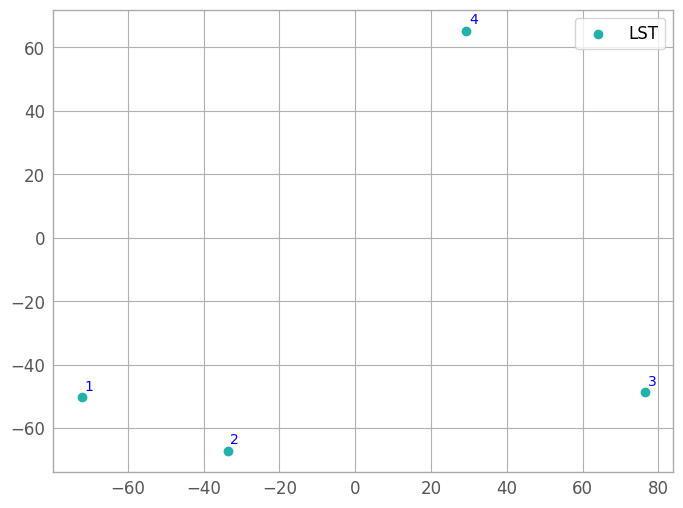

In [7]:
# Loop through all the telescopes
#for fov in array.table["fov"]:
#    print(fov)
colors = [
    'lightseagreen' if np.isclose(fov, 14.5356) else
    'blueviolet' if np.isclose(fov, 46.707) else 
    'green' if np.isclose(fov, 62.462) else
    'red'  # Default color if none of the conditions match
    for fov in array.table["fov"]
]
fov_labels = {
    'lightseagreen': 'LST',
    'blueviolet': 'MST',
    'green': 'SST'
}
for i in range(len(array.table)):
    plt.scatter(array.table['x'][i], array.table['y'][i], c=colors[i], label=fov_labels[colors[i]])

    # Annotate each point with the telescope ID
    #matplotlib.pyplot.annotate(text, xy, xytext=None, xycoords='data', textcoords=None, arrowprops=None, annotation_clip=None, **kwargs)
#Annotate the point xy with text text.
#In the simplest form, the text is placed at xy.
    plt.annotate(str(array.table["id"][i]),
                 (array.table['x'][i], array.table['y'][i]),  # Point position
                 textcoords="offset points",  # Text position relative to the point
                 xytext=(5, 5),  # Offset in pixels (to avoid overlapping the point)
                 ha='center', fontsize=10, color='blue')
handles, labels = plt.gca().get_legend_handles_labels()
#handles, labels like this is doing
    #plt.gca() gets the current Axes object, which is where your plot is
    #.get_legend_handles_labels()
        #handles: Returns a list of the graphical elements (e.g., lines, scatter plot points) that would appear in the legend.
        # labels: Returns the text labels associated with each graphical element in handles

by_label = dict(zip(labels, handles))  # Remove duplicate labels, the dictionary by the structure takes out the double 
plt.legend(by_label.values(), by_label.keys())
#by_label.values This is pulling out the unique graphical elements
# by_label.keys  This is retrieving the unique text 
plt.savefig("./different_telescopes.png", dpi=300, bbox_inches="tight")
plt.show() 

In [8]:
sub_groups={'1':[1,4], 
            '2': [2,3]}


In [9]:
def compute_center_of_gravity(group):
    x, y, z = group['x'], group['y'], group['z']
    cog_x = round(np.mean(x),2)
    cog_y = round(np.mean(y),2)
    cog_z = round(np.mean(z),2)
    return cog_x, cog_y, cog_z

# Function to create new telescope list with center of gravity
def create_new_group_list(tel_group):
    new_telescopes = []
    for group in tel_group.groups:
        print(tel_group.groups)
        print (group['focal'][0],round(group['radius'][0],2))
        #id_ = group["id"][0]
        cog = compute_center_of_gravity(group)
        focal, fov = group['focal'][0], round(group['radius'][0],2)  # Assuming same within a group
        new_telescopes.append([*cog, focal, fov])
    return new_telescopes

In [10]:
tel_group, labels, number_of_telescopes_subarray_1 =array.group_by(sub_groups)

In [11]:
new_telescopes = create_new_group_list(tel_group)

<TableGroups indices=[0 2 4]>
28.0 2.15
<TableGroups indices=[0 2 4]>
28.0 2.15


In [12]:
# Define the file path where you want to save the output
output_file_path = './LST_subarray.txt'

# Open the file in write mode
with open(output_file_path, 'w') as file:
    
    # Write a header
    #file.write("Group ID, X_Center, Y_Center, Z_Center, Focal Length, FOV\n")
    
    # Loop through all new telescopes (grouped telescopes)
    for i, telescope in enumerate(new_telescopes):
        # Assuming telescope is a list like [x_center, y_center, z_center, focal_length, fov]
        values = ' '.join(map(str, telescope))  # Convert all elements to string
        # Write the data to the file
        #print(values)
        file.write(f"{values}\n")

print(f"New telescope data has been written to {output_file_path}")


New telescope data has been written to ./LST_subarray.txt


In [13]:
array= LoadConfig("./LST_subarray.txt", frame=cta, pointing2src=True)

In [19]:

array.table.units = "deg"
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,-21.46,7.47,17.8,358.891,70.247,19.753,28.000,2.150,14.536,0.338,0.007,0.941,39.42
2,21.41,-57.92,7.65,1.082,69.746,20.254,28.000,2.150,14.536,0.346,-0.007,0.938,39.42


In [20]:
array.divergent_pointing(0.02, az=0,alt=70)

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  5.82it/s]
2it [00:00,  5.59it/s]


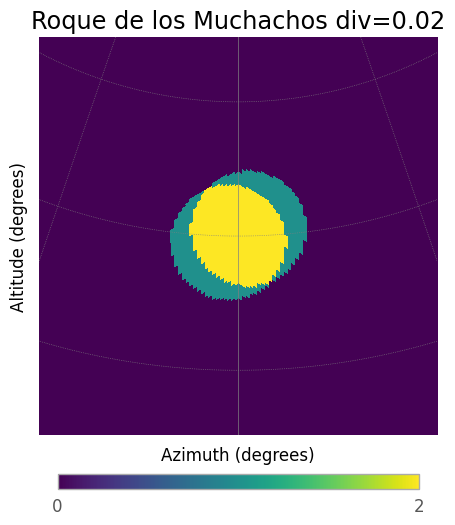

2it [00:00,  6.68it/s]


(18.451346231439246, 1.5771144278606966)

In [21]:
array.multiplicity_plot()
array.hFoV()

In [24]:
chosen_divergences=[0.0022,0.0043, 0.008, 0.01135, 0.01453, 0.01753, 0.02053, 0.02353, 0.02653, 0.02953, 0.05]
FoV_array_div_chosen=[]
av_multiplicity_array_div_chosen=[]

for divergence in chosen_divergences:
    array.divergent_pointing(divergence, az=0,alt=70)    
    FoV=array.hFoV(subarray_mult=number_of_telescopes_subarray_1)[0]
    print(f"The FoV of {divergence} is {FoV}")
    multiplicity=array.hFoV(subarray_mult=number_of_telescopes_subarray_1)[1]
    print(f"The multiplicity of {divergence} is {multiplicity}")
    FoV_array_div_chosen.append(FoV)
    av_multiplicity_array_div_chosen.append(multiplicity)
    

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  5.88it/s]


The FoV of 0.0022 is 14.910576165704635


2it [00:00,  6.61it/s]


The multiplicity of 0.0022 is 3.896218117854002
The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


...

The multiplicity of 0.02953 is 2.87890625
The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  7.29it/s]


The FoV of 0.05 is 23.775615293247583


2it [00:00,  6.97it/s]

The multiplicity of 0.05 is 2.4445670159955872


The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  6.21it/s]
2it [00:00,  5.53it/s]


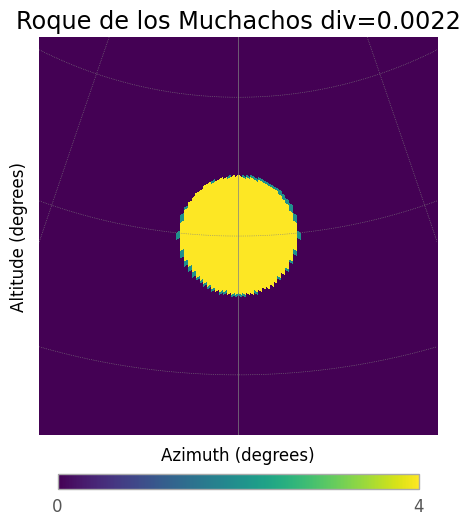

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  6.81it/s]
2it [00:00,  5.69it/s]


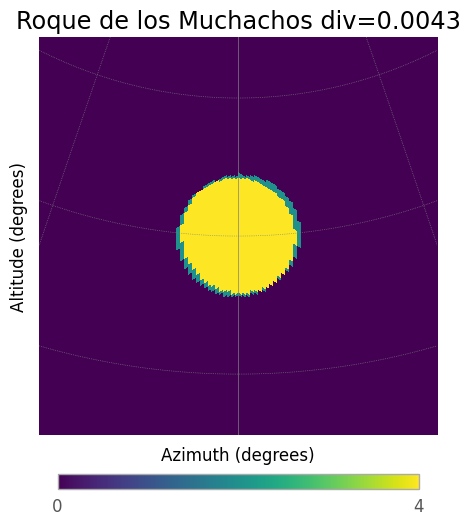

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  7.01it/s]
2it [00:00,  5.79it/s]


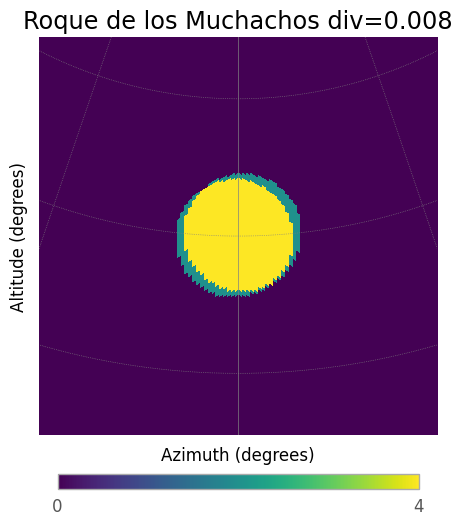

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  7.03it/s]
2it [00:00,  5.73it/s]


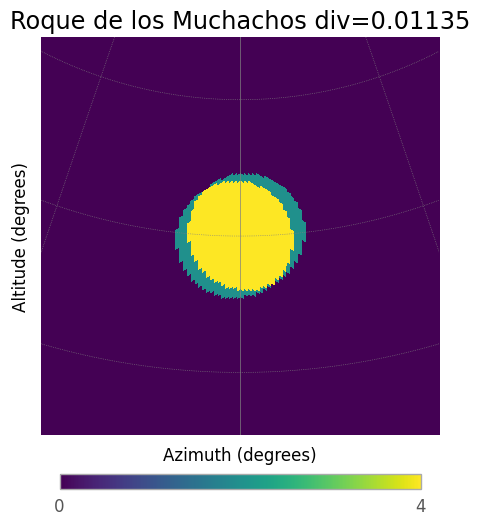

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  6.50it/s]
2it [00:00,  5.86it/s]


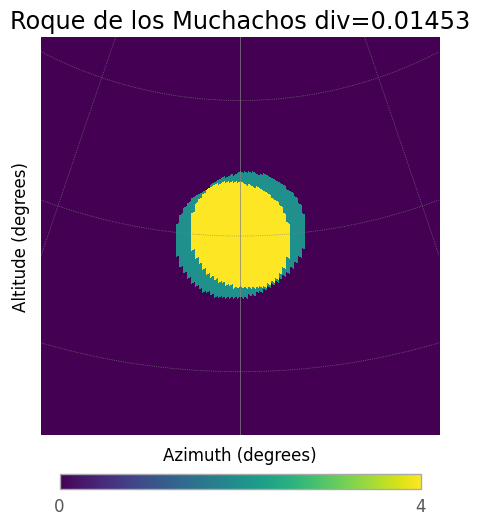

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  7.09it/s]
2it [00:00,  6.36it/s]


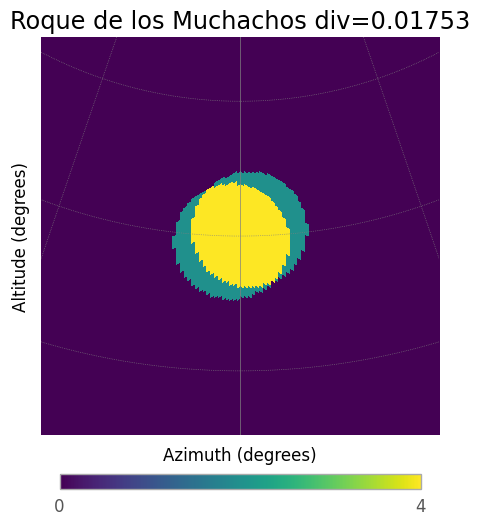

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  7.18it/s]
2it [00:00,  6.77it/s]


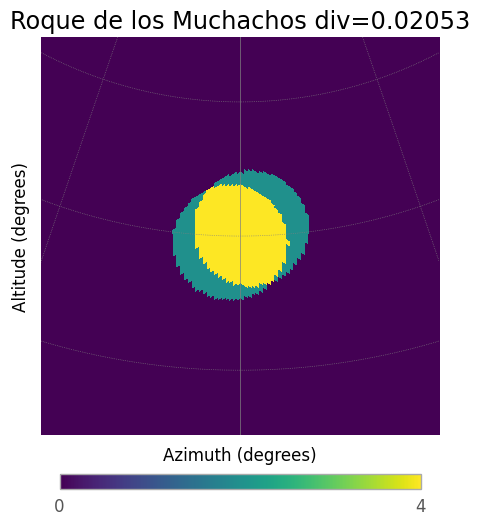

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  7.38it/s]
2it [00:00,  5.95it/s]


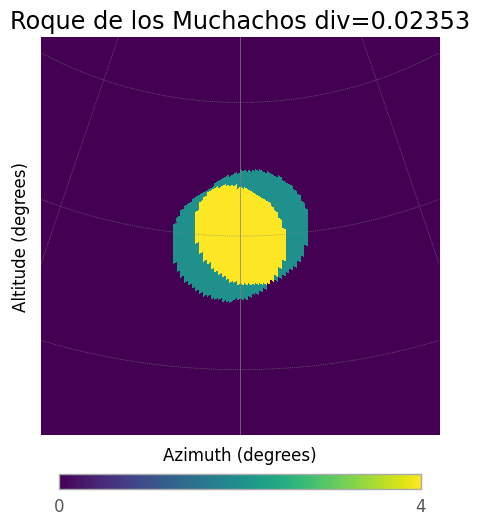

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  5.88it/s]
2it [00:00,  5.64it/s]


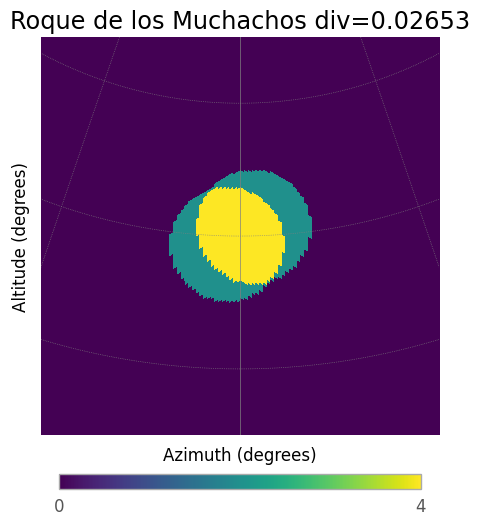

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  6.33it/s]
2it [00:00,  5.84it/s]


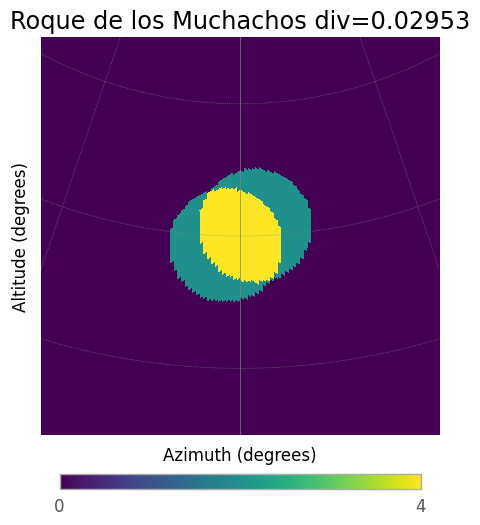

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  5.56it/s]
2it [00:00,  5.22it/s]


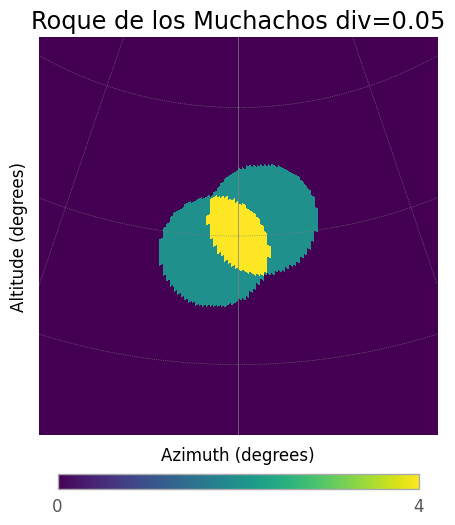

In [25]:
for divergence in chosen_divergences:
    array.divergent_pointing(div=divergence, az=0, alt=70)
    array.multiplicity_plot(number_of_telescopes_subarray_1)

In [32]:
def GRB_position(ra_start, dec_start, ra_final, dec_final):
   #Creating Sky coordinated object for the initial position
    c1 = SkyCoord(ra=ra_start * u.deg, dec=dec_start * u.deg, frame='icrs')
    c2 = SkyCoord(ra=ra_final * u.deg, dec=dec_final * u.deg, frame='icrs')
    #Now we need two thing the angular separation and the position angles(radius and theta)
    #Radius, what is the separation of this two coordianted
    separation = c1.separation(c2)
    #Theta, relative to the positions of the coordiantes what is the angle
    theta = c1.position_angle(c2)

    print(f"Separation, radius: {separation.to(u.deg):.3f}")
    print(f"Position angle(theta), altitude: {theta.to(u.deg):.3f}")
    return separation, theta
    
def multiplicity_plot(array, radius=None, subarray_mult=None, fig=None, alt=None, az=None):
    if array.table.units == 'rad':
        array.__convert_units__(toDeg=True)

    coord = array.get_pointing_coord(icrs=False)
    nside = 512
    map_multiplicity = np.zeros(hp.nside2npix(nside), dtype=np.float64)

    # Initialize Healpix coordinates
    counter = np.arange(0, hp.nside2npix(nside))
    ra, dec = hp.pix2ang(nside, counter, True, lonlat=True)
    coordinate = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

    # If subarray_mult is not provided, set all multiplicities to 1
    if subarray_mult is None:
        subarray_mult = np.ones(len(array.telescopes))

    # Iterate over telescopes
    for i, tel in tqdm.tqdm(enumerate(array.telescopes)):
        pointing = SkyCoord(ra=coord.az[i].degree, dec=coord.alt[i].degree, unit='deg')
        r_fov = np.arctan((tel.camera_radius / tel.focal).to(u.dimensionless_unscaled)).to(u.deg)
        mask = coordinate.separation(pointing) < r_fov
        map_multiplicity[mask] += subarray_mult[i]
  
    # Plotting
    R = np.sqrt(array.hFoV(m_cut=1)[0]/np.pi) + 5
    hp.cartview(map_multiplicity,
                rot=[array.pointing["az"].value, array.pointing["alt"].value],
                lonra=[-R, R], latra=[-R, R],
                nest=True, cmap='viridis',
                title=f"{array.frame.site} div={array.div}")
    plt.annotate('Azimuth (degrees)', xy=(0.5, -0.05), xycoords='axes fraction', ha='center', va='center')
    plt.annotate('Altitude (degrees)', xy=(-0.05, 0.5), xycoords='axes fraction', ha='center', va='center', rotation='vertical')
    hp.graticule(dpar=5, dmer=5, coord='G', color='gray', lw=0.5)


    # ---- ADD A RING HERE ----
    az_center = az * u.deg
    alt_center= alt * u.deg
    center = SkyCoord(az=az_center, alt=alt_center, frame='altaz')
    angles = Angle(np.linspace(0, 2*np.pi, 200), unit=u.rad)  # Position angles around the center
    ring_radius = radius *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
  
   
    hp.projplot(lon, lat, '-', lonlat=True, linewidth=1.5, color='orange')
    print(az)
    print(alt)
##MST FoV
    ring_radius = 2.15 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    hp.projplot(lon, lat, '-', lonlat=True, linewidth=1.5, color='red')



    ## The different telescopes
    ring_radius = 2 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)
     
    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='maroon')


    ring_radius = 1.5 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   
    
    #lon = az_ring.value
    #lat = alt_ring.value
   
    hp.projplot(lon, lat, '--', lonlat=True, linewidth=1.5, color='white')


    
    center = SkyCoord(az=az*u.deg, alt=alt*u.deg, frame='altaz')

    # Offset at angle θ = 45°
    theta = 0 * u.deg
    separation = 0 * u.deg
    point_on_ring = center.directional_offset_by(position_angle=theta, separation=separation)

# Plot it
    hp.projscatter(point_on_ring.az.deg, point_on_ring.alt.deg, lonlat=True,
               marker='x', color='red', s=100)
    # -------------------------- 

    plt.show()

The barycenter -0.025000000000000355
The barycenter -25.225
The barycenter 12.725000000000001


2it [00:00,  6.13it/s]
2it [00:00,  5.57it/s]


0
70


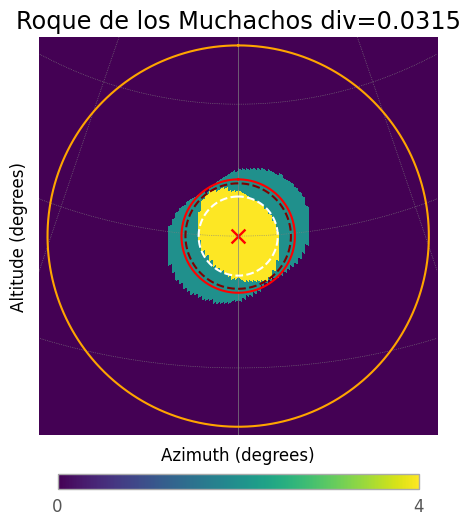

In [33]:
array.divergent_pointing(div=0.0315, az=0, alt=70)
multiplicity_plot(array, 7.23, number_of_telescopes_subarray_1, alt=70, az=0)